Project root: /Users/trinetradhararg/tata-power-ev-charging-analytics
Sessions file exists: True


Sessions loaded: 1,087,262
Customers loaded: 8,000
Stations loaded: 150
INTERVENTION STRATEGY
Sessions loaded: 1,087,262
Customers loaded: 8,000
Stations loaded: 150
Customer behaviour records: 8,000

Basic validation passed.

TOP INTERVENTION CITIES
     city  customers  peak_sessions  eligible_customers  eligible_share  avg_intervention_score  estimated_shiftable_peak_sessions  shiftable_share
Delhi NCR        968          40645                 580        0.599174               49.245275                          27069.453         0.665997
Bengaluru        970          40182                 569        0.586598               49.088592                          26818.814         0.667434
   Mumbai        934          37936                 537        0.574946               49.067752                          25239.548         0.665319
Hyderabad        774          33407                 437        0.564599               49.186237                          22292.521         0.667301
  Chennai

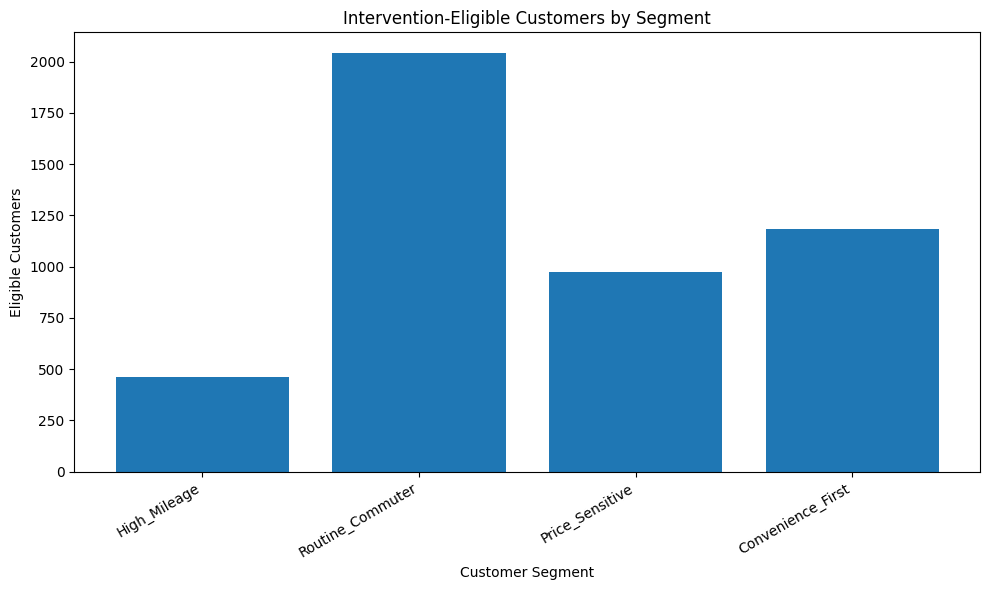

['city', 'customers', 'eligible_customers', 'eligible_share', 'avg_intervention_score', 'avg_flexibility', 'peak_sessions', 'estimated_shiftable_peak_sessions', 'shiftable_share']


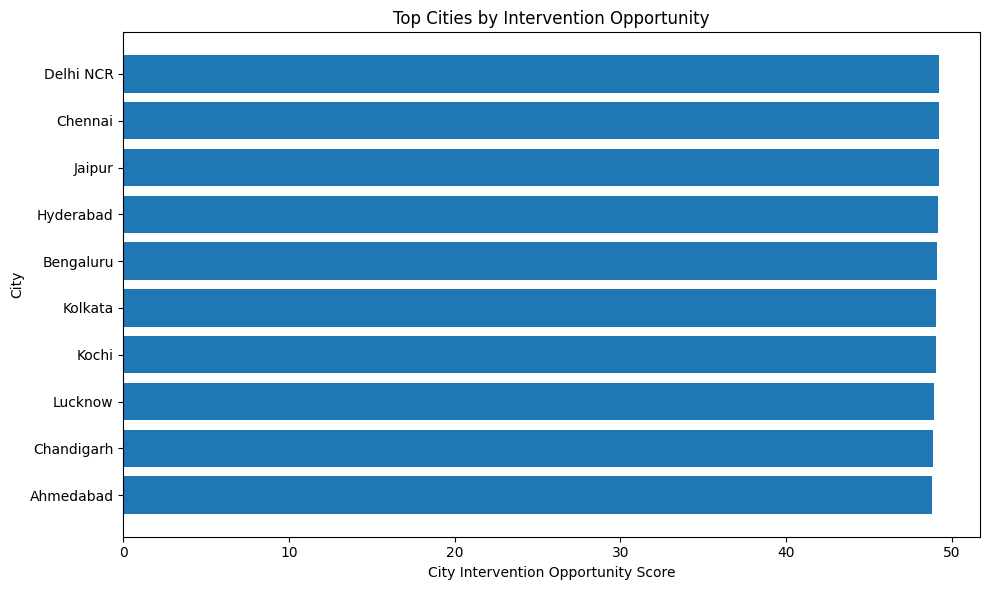

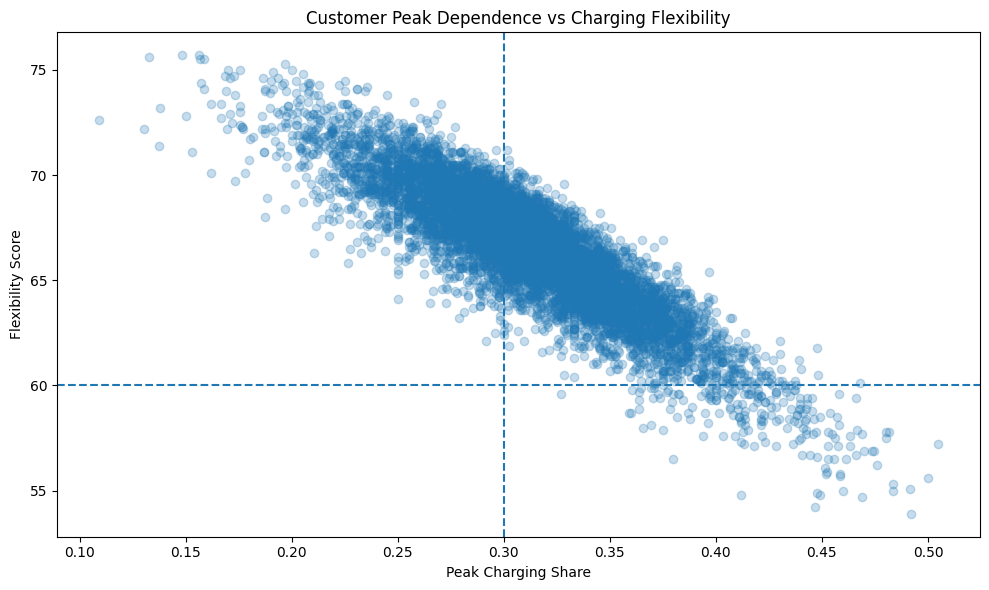

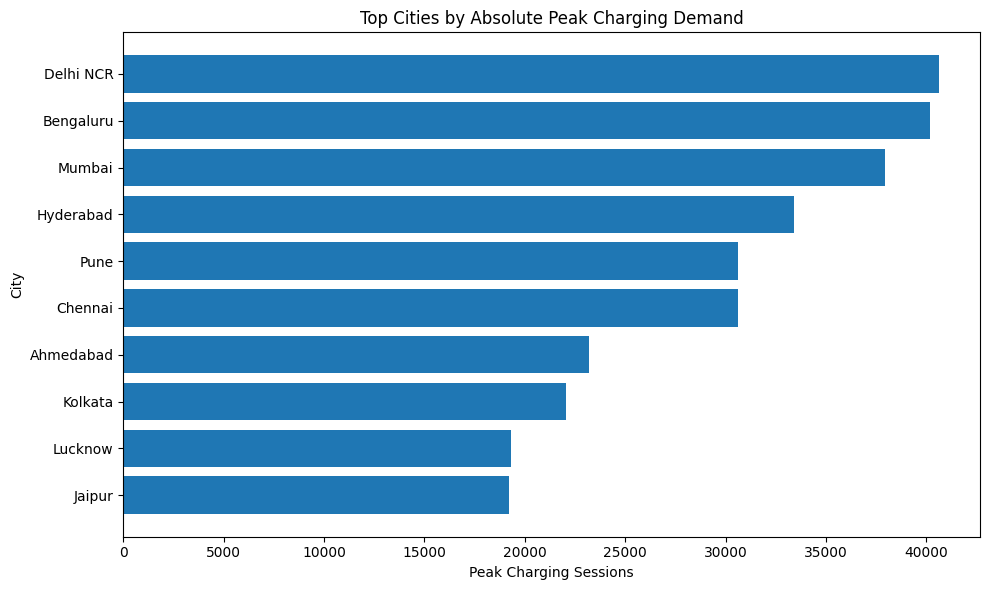



INTERVENTION STRATEGY ANALYSIS COMPLETE
Customers analysed: 8,000
Intervention-eligible customers: 4,661
Eligible customer share: 58.3%
Peak sessions: 331,879
Estimated shiftable peak sessions: 221,272
Estimated shiftable share: 66.7%

Top intervention city:
Delhi NCR

Top intervention segment:
High_Mileage

Outputs saved:
- outputs/tables/intervention_customer_priority.csv
- outputs/tables/intervention_segment_opportunity.csv
- outputs/tables/intervention_city_opportunity.csv
- outputs/tables/top_intervention_targets.csv

Figures saved:
- outputs/figures/eligible_customers_by_segment.png
- outputs/figures/top_cities_intervention_opportunity.png
- outputs/figures/peak_dependence_vs_flexibility.png
- outputs/figures/city_peak_demand.png

Stage 4 complete.


In [21]:
# ============================================================
# 04_INTERVENTION_STRATEGY.ipynb
# Tata Power EV Charging Analytics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. SETUP
# ============================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Find the project root by locating the data folder
BASE_PATH = Path.cwd()

if not (BASE_PATH / "data/raw/sessions.csv").exists():
    BASE_PATH = BASE_PATH.parent

SESSIONS_PATH = BASE_PATH / "data/raw/sessions.csv"
CUSTOMERS_PATH = BASE_PATH / "data/raw/customers.csv"
STATIONS_PATH = BASE_PATH / "data/raw/stations.csv"

print("Project root:", BASE_PATH)
print("Sessions file exists:", SESSIONS_PATH.exists())

CUSTOMER_BEHAVIOUR_PATH = (
    BASE_PATH / "outputs/tables/customer_behaviour.csv"
)

CUSTOMER_SEGMENT_PATH = (
    BASE_PATH / "outputs/tables/customer_segment_behaviour.csv"
)

PEAK_DEPENDENCE_PATH = (
    BASE_PATH / "outputs/tables/peak_dependence_summary.csv"
)

OUTPUT_TABLE_PATH = BASE_PATH / "outputs/tables"
OUTPUT_FIGURE_PATH = BASE_PATH / "outputs/figures"

OUTPUT_TABLE_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_PATH.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. LOAD DATA
# ============================================================

sessions_df = pd.read_csv(
    SESSIONS_PATH,
    usecols=[
        "session_id",
        "customer_id",
        "station_id",
        "start_timestamp",
        "energy_kwh",
    ]
)

customers_df = pd.read_csv(CUSTOMERS_PATH)

stations_df = pd.read_csv(STATIONS_PATH)

print(f"Sessions loaded: {len(sessions_df):,}")
print(f"Customers loaded: {len(customers_df):,}")
print(f"Stations loaded: {len(stations_df):,}")

customer_behaviour = pd.read_csv(
    CUSTOMER_BEHAVIOUR_PATH
)


print("INTERVENTION STRATEGY")
print("=" * 60)

print(f"Sessions loaded: {len(sessions_df):,}")
print(f"Customers loaded: {len(customers_df):,}")
print(f"Stations loaded: {len(stations_df):,}")
print(
    f"Customer behaviour records: "
    f"{len(customer_behaviour):,}"
)


# ============================================================
# 3. BASIC VALIDATION
# ============================================================

assert sessions_df["session_id"].is_unique
assert customers_df["customer_id"].is_unique
assert stations_df["station_id"].is_unique

assert sessions_df["customer_id"].isin(
    customers_df["customer_id"]
).all()

assert sessions_df["station_id"].isin(
    stations_df["station_id"]
).all()

assert customer_behaviour["customer_id"].isin(
    customers_df["customer_id"]
).all()

print("\nBasic validation passed.")


# ============================================================
# 4. PREPARE SESSION DATA
# ============================================================

sessions_df["start_timestamp"] = pd.to_datetime(
    sessions_df["start_timestamp"]
)

sessions_df["hour"] = (
    sessions_df["start_timestamp"].dt.hour
)

sessions_df["date"] = (
    sessions_df["start_timestamp"].dt.date
)


# Peak definition used throughout the project.
#
# Peak hours:
# 07:00–10:00
# 17:00–21:00
#
# This is an analytical assumption for the intervention
# analysis and should be clearly stated in the project.

sessions_df["is_peak"] = (
    sessions_df["hour"].between(7, 9)
    |
    sessions_df["hour"].between(17, 20)
)


# ============================================================
# 5. CUSTOMER-LEVEL INTERVENTION METRICS
# ============================================================

customer_session_metrics = (
    sessions_df
    .groupby("customer_id")
    .agg(
        total_sessions=("session_id", "count"),
        peak_sessions=("is_peak", "sum"),
        total_energy_kwh=("energy_kwh", "sum"),
        avg_energy_kwh=("energy_kwh", "mean"),
    )
    .reset_index()
)


customer_session_metrics["peak_share"] = (
    customer_session_metrics["peak_sessions"]
    / customer_session_metrics["total_sessions"]
)


# ============================================================
# 6. COMBINE CUSTOMER BEHAVIOUR
# ============================================================

customer_analysis = (
    customer_behaviour
    .merge(
        customers_df[
            [
                "customer_id",
                "customer_segment",
            ]
        ],
        on="customer_id",
        how="left",
    )
)


# ------------------------------------------------------------
# Handle customers with no observed sessions safely.
# ------------------------------------------------------------

for col in [
    "total_sessions",
    "peak_sessions",
    "total_energy_kwh",
    "avg_energy_kwh",
]:
    customer_analysis[col] = (
        customer_analysis[col]
        .fillna(0)
    )


customer_analysis["peak_share"] = (
    customer_analysis["peak_share"]
    .fillna(0)
)


# ============================================================
# 7. DEFINE INTERVENTION ELIGIBILITY
# ============================================================

# Customers are considered eligible when:
#
# 1. They have meaningful peak dependence
# 2. They have meaningful charging flexibility
#
# These thresholds are analytical targeting rules,
# not claims about Tata Power's actual programme.

PEAK_SHARE_THRESHOLD = 0.30
FLEXIBILITY_THRESHOLD = 60


customer_analysis["eligible_for_intervention"] = (
    (
        customer_analysis["peak_share"]
        >= PEAK_SHARE_THRESHOLD
    )
    &
    (
        customer_analysis["flexibility_score"]
        >= FLEXIBILITY_THRESHOLD
    )
)


# ============================================================
# 8. CUSTOMER INTERVENTION SCORE
# ============================================================

# The score combines:
#
# Peak dependence       -> 40%
# Flexibility           -> 40%
# Charging frequency    -> 20%
#
# This is designed for prioritisation rather than
# predicting customer behaviour.

peak_component = (
    customer_analysis["peak_share"]
    .clip(0, 1)
    * 100
)

flexibility_component = (
    customer_analysis["flexibility_score"]
    .clip(0, 100)
)

frequency_component = (
    customer_analysis["total_sessions"]
    .rank(pct=True)
    * 100
)

customer_analysis["intervention_score"] = (
    0.40 * peak_component
    + 0.40 * flexibility_component
    + 0.20 * frequency_component
)


# ============================================================
# 9. CUSTOMER PRIORITY BANDS
# ============================================================

customer_analysis["priority_band"] = pd.cut(
    customer_analysis["intervention_score"],
    bins=[
        -np.inf,
        50,
        65,
        80,
        np.inf,
    ],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High",
    ],
)


# ============================================================
# 10. CUSTOMER-LEVEL OUTPUT
# ============================================================

customer_analysis_output = customer_analysis[
    [
        "customer_id",
        "customer_segment_x",
        "total_sessions",
        "peak_sessions",
        "peak_share",
        "total_energy_kwh",
        "avg_energy_kwh",
        "flexibility_score",
        "eligible_for_intervention",
        "intervention_score",
        "priority_band",
    ]
].copy()


customer_analysis_output = (
    customer_analysis_output
    .sort_values(
        "intervention_score",
        ascending=False,
    )
)


customer_analysis_output.to_csv(
    OUTPUT_TABLE_PATH
    / "intervention_customer_priority.csv",
    index=False,
)


# ============================================================
# 11. SEGMENT-LEVEL OPPORTUNITY
# ============================================================

segment_opportunity = (
    customer_analysis
    .groupby("customer_segment_x")
    .agg(
        customers=("customer_id", "count"),
        eligible_customers=(
            "eligible_for_intervention",
            "sum",
        ),
        avg_peak_share=("peak_share", "mean"),
        avg_flexibility=(
            "flexibility_score",
            "mean",
        ),
        avg_intervention_score=(
            "intervention_score",
            "mean",
        ),
        total_sessions=(
            "total_sessions",
            "sum",
        ),
        peak_sessions=(
            "peak_sessions",
            "sum",
        ),
    )
    .reset_index()
)


segment_opportunity["eligible_share"] = (
    segment_opportunity["eligible_customers"]
    / segment_opportunity["customers"]
)


segment_opportunity["peak_session_share"] = (
    segment_opportunity["peak_sessions"]
    / segment_opportunity["total_sessions"]
)


segment_opportunity = (
    segment_opportunity
    .sort_values(
        "avg_intervention_score",
        ascending=False,
    )
)


segment_opportunity.to_csv(
    OUTPUT_TABLE_PATH
    / "intervention_segment_opportunity.csv",
    index=False,
)


# ============================================================
# 12. ATTACH STATION / CITY INFORMATION
# ============================================================

session_city = (
    sessions_df[
        [
            "customer_id",
            "station_id",
            "is_peak",
            "energy_kwh",
        ]
    ]
    .merge(
        stations_df[
            [
                "station_id",
                "city",
                "station_type",
            ]
        ],
        on="station_id",
        how="left",
    )
)


# ============================================================
# 13. CITY-LEVEL DEMAND
# ============================================================

city_demand = (
    session_city
    .groupby("city")
    .agg(
        total_sessions=(
            "customer_id",
            "count",
        ),
        peak_sessions=(
            "is_peak",
            "sum",
        ),
        total_energy_kwh=(
            "energy_kwh",
            "sum",
        ),
        stations=(
            "station_id",
            "nunique",
        ),
    )
    .reset_index()
)


city_demand["peak_share"] = (
    city_demand["peak_sessions"]
    / city_demand["total_sessions"]
)


# ============================================================
# 14. CITY-LEVEL CUSTOMER ELIGIBILITY
# ============================================================

# Link customers to the cities where they charge most often.

customer_city = (
    session_city
    .groupby(
        [
            "customer_id",
            "city",
        ]
    )
    .size()
    .reset_index(
        name="sessions"
    )
)


customer_primary_city = (
    customer_city
    .sort_values(
        [
            "customer_id",
            "sessions",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .drop_duplicates(
        "customer_id"
    )
)


city_customer_analysis = customer_analysis.copy()


city_eligibility = (
    city_customer_analysis
    .groupby("city")
    .agg(
        customers=("customer_id", "count"),
        eligible_customers=(
            "eligible_for_intervention",
            "sum",
        ),
        avg_intervention_score=(
            "intervention_score",
            "mean",
        ),
        avg_flexibility=(
            "flexibility_score",
            "mean",
        ),
    )
    .reset_index()
)


city_eligibility["eligible_share"] = (
    city_eligibility["eligible_customers"]
    / city_eligibility["customers"]
)


# ============================================================
# 15. COMBINE CITY DEMAND + ELIGIBILITY
# ============================================================

city_opportunity = (
    city_demand
    .merge(
        city_eligibility,
        on="city",
        how="left",
    )
)


city_opportunity[
    [
        "eligible_customers",
        "avg_intervention_score",
        "avg_flexibility",
        "eligible_share",
    ]
] = (
    city_opportunity[
        [
            "eligible_customers",
            "avg_intervention_score",
            "avg_flexibility",
            "eligible_share",
        ]
    ]
    .fillna(0)
)


# ============================================================
# 16. CITY INTERVENTION OPPORTUNITY SCORE
# ============================================================

# We want to prioritise cities that have:
#
# - large charging demand
# - high peak dependence
# - meaningful intervention-eligible population
#
# Percentile normalisation prevents large cities from
# automatically dominating every component.

def percentile_score(series):
    return (
        series.rank(
            pct=True,
            method="average",
        )
        * 100
    )


city_opportunity["demand_score"] = (
    percentile_score(
        city_opportunity["total_sessions"]
    )
)

city_opportunity["peak_score"] = (
    percentile_score(
        city_opportunity["peak_share"]
    )
)

city_opportunity["eligibility_score"] = (
    percentile_score(
        city_opportunity["eligible_customers"]
    )
)


city_opportunity["avg_intervention_score"] = (
    0.40
    * city_opportunity["demand_score"]
    +
    0.30
    * city_opportunity["peak_score"]
    +
    0.30
    * city_opportunity["eligibility_score"]
)


city_opportunity = (
    city_opportunity
    .sort_values(
        "avg_intervention_score",
        ascending=False,
    )
)


# ============================================================
# 17. ESTIMATE SHIFTABLE PEAK SESSIONS
# ============================================================

# We do NOT assume every peak session can be shifted.
#
# Instead, we use the customer's flexibility score as
# a proxy for the fraction of peak behaviour that could
# potentially be influenced.
#
# This is an analytical opportunity estimate, not a
# forecast of actual programme impact.

customer_analysis["estimated_shiftable_peak_sessions"] = (
    customer_analysis["peak_sessions"]
    * (
        customer_analysis["flexibility_score"]
        / 100
    )
)


estimated_shiftable_sessions = (
    customer_analysis[
        "estimated_shiftable_peak_sessions"
    ]
    .sum()
)


total_peak_sessions = (
    customer_analysis[
        "peak_sessions"
    ]
    .sum()
)


estimated_shiftable_share = (
    estimated_shiftable_sessions
    / total_peak_sessions
)


# ============================================================
# 18. CITY SHIFTABLE OPPORTUNITY
# ============================================================

city_customer_shift = customer_analysis.copy()


city_shiftable = (
    city_customer_shift
    .groupby("city")
    .agg(
        peak_sessions=(
            "peak_sessions",
            "sum",
        ),
        estimated_shiftable_peak_sessions=(
            "estimated_shiftable_peak_sessions",
            "sum",
        ),
        eligible_customers=(
            "eligible_for_intervention",
            "sum",
        ),
    )
    .reset_index()
)


city_shiftable["shiftable_share"] = (
    city_shiftable[
        "estimated_shiftable_peak_sessions"
    ]
    / city_shiftable["peak_sessions"]
)


city_opportunity = (
    city_eligibility
    .merge(
        city_shiftable,
        on="city",
        how="left",
        suffixes=("", "_shift")
    )
)

city_opportunity["shiftable_share"] = (
    city_opportunity["estimated_shiftable_peak_sessions"]
    / city_opportunity["peak_sessions"]
).fillna(0)

city_opportunity["eligible_customers"] = (
    city_opportunity["eligible_customers"]
    .fillna(0)
)

city_opportunity = city_opportunity[
    [
        "city",
        "customers",
        "eligible_customers",
        "eligible_share",
        "avg_intervention_score",
        "avg_flexibility",
        "peak_sessions",
        "estimated_shiftable_peak_sessions",
        "shiftable_share",
    ]
]


# Remove duplicate eligibility column created by merge.

if "eligible_customers_y" in city_opportunity.columns:
    city_opportunity = city_opportunity.drop(
        columns=["eligible_customers_y"]
    )


# ============================================================
# 19. CITY OUTPUT
# ============================================================

city_opportunity.to_csv(
    OUTPUT_TABLE_PATH
    / "intervention_city_opportunity.csv",
    index=False,
)


# ============================================================
# 20. TOP INTERVENTION TARGETS
# ============================================================

top_customer_targets = (
    customer_analysis[
        customer_analysis[
            "eligible_for_intervention"
        ]
    ]
    .sort_values(
        [
            "intervention_score",
            "peak_sessions",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(100)
)


top_customer_targets.to_csv(
    OUTPUT_TABLE_PATH
    / "top_intervention_targets.csv",
    index=False,
)


# ============================================================
# 21. TOP CITIES
# ============================================================

top_cities = (
    city_opportunity
    .sort_values(
        "estimated_shiftable_peak_sessions",
        ascending=False
    )
    .head(10)
    [
        [
            "city",
            "customers",
            "peak_sessions",
            "eligible_customers",
            "eligible_share",
            "avg_intervention_score",
            "estimated_shiftable_peak_sessions",
            "shiftable_share",
        ]
    ]
)

print("\nTOP INTERVENTION CITIES")
print("=" * 60)

print(
    top_cities.to_string(
        index=False
    )
)


# ============================================================
# 22. TOP CUSTOMER SEGMENTS
# ============================================================

print("\nSEGMENT OPPORTUNITY")
print("=" * 60)

print(
    segment_opportunity.to_string(
        index=False
    )
)


# ============================================================
# 23. KEY BUSINESS METRICS
# ============================================================

eligible_customers = (
    customer_analysis[
        "eligible_for_intervention"
    ]
    .sum()
)

total_customers = len(
    customer_analysis
)

eligible_customer_share = (
    eligible_customers
    / total_customers
)


print("\nKEY INTERVENTION METRICS")
print("=" * 60)

print(
    f"Total customers: "
    f"{total_customers:,}"
)

print(
    f"Eligible customers: "
    f"{eligible_customers:,}"
)

print(
    f"Eligible customer share: "
    f"{eligible_customer_share:.1%}"
)

print(
    f"Total peak sessions: "
    f"{total_peak_sessions:,.0f}"
)

print(
    f"Estimated shiftable peak sessions: "
    f"{estimated_shiftable_sessions:,.0f}"
)

print(
    f"Estimated shiftable share of peak sessions: "
    f"{estimated_shiftable_share:.1%}"
)


# ============================================================
# 24. FIGURE 1 — ELIGIBLE CUSTOMERS BY SEGMENT
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    segment_opportunity["customer_segment_x"],
    segment_opportunity["eligible_customers"]
)

plt.title(
    "Intervention-Eligible Customers by Segment"
)

plt.xlabel("Customer Segment")
plt.ylabel("Eligible Customers")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_PATH
    / "eligible_customers_by_segment.png",
    dpi=150
)

plt.show()

print(city_opportunity.columns.tolist())
# ============================================================
# 25. FIGURE 2 — CITY OPPORTUNITY
# ============================================================

plot_data = (
    city_opportunity
    .head(10)
    .sort_values("avg_intervention_score")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["city"],
    plot_data[
        "avg_intervention_score"
    ],
)

plt.title(
    "Top Cities by Intervention Opportunity"
)

plt.xlabel(
    "City Intervention Opportunity Score"
)

plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_PATH
    / "top_cities_intervention_opportunity.png",
    dpi=150,
)

plt.show()


# ============================================================
# 26. FIGURE 3 — PEAK VS FLEXIBILITY
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_analysis["peak_share"],
    customer_analysis["flexibility_score"],
    alpha=0.25,
)

plt.axvline(
    PEAK_SHARE_THRESHOLD,
    linestyle="--",
)

plt.axhline(
    FLEXIBILITY_THRESHOLD,
    linestyle="--",
)

plt.title(
    "Customer Peak Dependence vs Charging Flexibility"
)

plt.xlabel(
    "Peak Charging Share"
)

plt.ylabel(
    "Flexibility Score"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_PATH
    / "peak_dependence_vs_flexibility.png",
    dpi=150,
)

plt.show()


# ============================================================
# 27. FIGURE 4 — CITY PEAK DEMAND
# ============================================================

plot_data = (
    city_opportunity
    .sort_values(
        "peak_sessions",
        ascending=False,
    )
    .head(10)
    .sort_values(
        "peak_sessions"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["city"],
    plot_data["peak_sessions"],
)

plt.title(
    "Top Cities by Absolute Peak Charging Demand"
)

plt.xlabel(
    "Peak Charging Sessions"
)

plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_PATH
    / "city_peak_demand.png",
    dpi=150,
)

plt.show()


# ============================================================
# 28. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("INTERVENTION STRATEGY ANALYSIS COMPLETE")
print("=" * 70)

print(
    f"Customers analysed: "
    f"{total_customers:,}"
)

print(
    f"Intervention-eligible customers: "
    f"{eligible_customers:,}"
)

print(
    f"Eligible customer share: "
    f"{eligible_customer_share:.1%}"
)

print(
    f"Peak sessions: "
    f"{total_peak_sessions:,.0f}"
)

print(
    f"Estimated shiftable peak sessions: "
    f"{estimated_shiftable_sessions:,.0f}"
)

print(
    f"Estimated shiftable share: "
    f"{estimated_shiftable_share:.1%}"
)

print("\nTop intervention city:")

if len(top_cities) > 0:
    print(
        top_cities.iloc[0]["city"]
    )

print("\nTop intervention segment:")

if len(segment_opportunity) > 0:
    print(
        segment_opportunity.iloc[0]["customer_segment_x"]
    )

print("\nOutputs saved:")
print(
    "- outputs/tables/intervention_customer_priority.csv"
)
print(
    "- outputs/tables/intervention_segment_opportunity.csv"
)
print(
    "- outputs/tables/intervention_city_opportunity.csv"
)
print(
    "- outputs/tables/top_intervention_targets.csv"
)

print("\nFigures saved:")
print(
    "- outputs/figures/eligible_customers_by_segment.png"
)
print(
    "- outputs/figures/top_cities_intervention_opportunity.png"
)
print(
    "- outputs/figures/peak_dependence_vs_flexibility.png"
)
print(
    "- outputs/figures/city_peak_demand.png"
)

print("\nStage 4 complete.")